<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/05_Temporal_ML_Feature_Construction_and_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import gc

print("Notebook 5 started successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Notebook 5 started successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets"
feature_path = f"{base_path}/Features"
candidate_path = f"{base_path}/Candidate_Training_Data"

print("Base path:", base_path)
print("Feature path:", feature_path)
print("Candidate path:", candidate_path)
print("\nCandidate folder exists:", os.path.exists(candidate_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base path: /content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets
Feature path: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Features
Candidate path: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Candidate_Training_Data

Candidate folder exists: True


In [ ]:
chunk_files = sorted([
    f for f in os.listdir(candidate_path)
    if f.startswith("candidate_training_chunk_")
    and f.endswith(".parquet")
])

print("Number of candidate chunks:", len(chunk_files))
print("First chunk:", chunk_files[0])
print("Last chunk:", chunk_files[-1])

Number of candidate chunks: 99
First chunk: candidate_training_chunk_001.parquet
Last chunk: candidate_training_chunk_099.parquet


In [ ]:
user_features = pd.read_parquet(
    f"{feature_path}/user_features.parquet"
)

product_features = pd.read_parquet(
    f"{feature_path}/product_features.parquet"
)

user_basket_features = pd.read_parquet(
    f"{feature_path}/user_basket_features.parquet"
)

print("User features:", user_features.shape)
print("Product features:", product_features.shape)
print("User basket features:", user_basket_features.shape)

print("\nMemory-safe feature tables loaded.")

User features: (206209, 5)
Product features: (49677, 6)
User basket features: (206209, 4)

Memory-safe feature tables loaded.


In [ ]:
orders = pd.read_csv(
    f"{base_path}/orders.csv",
    usecols=[
        "order_id",
        "user_id",
        "eval_set",
        "order_number"
    ],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "eval_set": "category",
        "order_number": "int16"
    }
)

prior_orders = orders[
    orders["eval_set"] == "prior"
][[
    "order_id",
    "user_id",
    "order_number"
]].copy()

print("Orders:", orders.shape)
print("Prior orders:", prior_orders.shape)
print("Unique users:", orders["user_id"].nunique())
print("Unique prior orders:", prior_orders["order_id"].nunique())

Orders: (3421083, 4)
Prior orders: (3214874, 3)
Unique users: 206209
Unique prior orders: 3214874


In [ ]:
prior_interactions = pd.read_csv(
    f"{base_path}/order_products_prior.csv",
    usecols=["order_id", "product_id"],
    dtype={
        "order_id": "int32",
        "product_id": "int32"
    }
)

historical_interactions = prior_interactions.merge(
    prior_orders,
    on="order_id",
    how="left"
)

print("Prior interactions:", prior_interactions.shape)
print("Historical interactions:", historical_interactions.shape)
print("Missing order numbers:", historical_interactions["order_number"].isna().sum())
print("Unique products:", historical_interactions["product_id"].nunique())

Prior interactions: (32434489, 2)
Historical interactions: (32434489, 4)
Missing order numbers: 0
Unique products: 49677


In [ ]:
user_product_history = (
    historical_interactions
    .groupby(["user_id", "product_id"])["order_number"]
    .agg(
        first_order="min",
        last_order="max",
        times_purchased="count"
    )
    .reset_index()
)

print("User-product history:", user_product_history.shape)
print("Unique users:", user_product_history["user_id"].nunique())
print("Unique products:", user_product_history["product_id"].nunique())
print("Missing values:", user_product_history.isna().sum().sum())

User-product history: (13307953, 5)
Unique users: 206209
Unique products: 49677
Missing values: 0


In [ ]:
user_product_history = (
    user_product_history
    .sort_values(["user_id", "product_id"])
    .reset_index(drop=True)
)

print("Sorted successfully.")
print("Shape:", user_product_history.shape)
print("Columns:", user_product_history.columns.tolist())

Sorted successfully.
Shape: (13307953, 5)
Columns: ['user_id', 'product_id', 'first_order', 'last_order', 'times_purchased']


In [ ]:
user_order_sizes = (
    historical_interactions
    .groupby(["user_id", "order_number"])
    .size()
    .reset_index(name="items_in_order")
)

print("User-order statistics:", user_order_sizes.shape)
print("Unique users:", user_order_sizes["user_id"].nunique())
print("Unique orders:", user_order_sizes["order_number"].nunique())
print("Average basket size:", round(user_order_sizes["items_in_order"].mean(), 2))

User-order statistics: (3214874, 3)
Unique users: 206209
Unique orders: 99
Average basket size: 10.09


In [ ]:
sample_chunk = pd.read_parquet(
    os.path.join(candidate_path, chunk_files[0])
)

print("Sample chunk shape:", sample_chunk.shape)
print("Columns:", sample_chunk.columns.tolist())
print("Unique target orders:", sample_chunk["order_id"].nunique())
print("Unique users:", sample_chunk["user_id"].nunique())
print("Positive candidates:", sample_chunk["in_next_basket"].sum())
print("Negative candidates:", (sample_chunk["in_next_basket"] == 0).sum())

Sample chunk shape: (735366, 5)
Columns: ['order_id', 'user_id', 'order_number', 'product_id', 'in_next_basket']
Unique target orders: 4855
Unique users: 1842
Positive candidates: 35299
Negative candidates: 700067


In [ ]:
order_context = pd.read_csv(
    f"{base_path}/orders.csv",
    usecols=[
        "order_id",
        "order_dow",
        "order_hour_of_day",
        "days_since_prior_order"
    ],
    dtype={
        "order_id": "int32",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32"
    }
)

sample_chunk = sample_chunk.merge(
    order_context,
    on="order_id",
    how="left"
)

print("Shape after merge:", sample_chunk.shape)
print("Missing context values:")
print(sample_chunk[
    ["order_dow", "order_hour_of_day", "days_since_prior_order"]
].isna().sum())

Shape after merge: (735366, 8)
Missing context values:
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


In [ ]:
sample_users = sample_chunk["user_id"].unique()

sample_history = historical_interactions[
    historical_interactions["user_id"].isin(sample_users)
][["user_id", "product_id", "order_number"]].copy()

candidate_history = sample_chunk[
    ["order_id", "user_id", "order_number", "product_id"]
].merge(
    sample_history,
    on=["user_id", "product_id"],
    how="left",
    suffixes=("_target", "_history")
)

candidate_history = candidate_history[
    candidate_history["order_number_history"]
    < candidate_history["order_number_target"]
].copy()

candidate_history_features = (
    candidate_history
    .groupby(
        ["order_id", "user_id", "order_number_target", "product_id"]
    )
    .agg(
        times_purchased_before=("order_number_history", "count"),
        first_purchase_before=("order_number_history", "min"),
        last_purchase_before=("order_number_history", "max")
    )
    .reset_index()
    .rename(columns={"order_number_target": "order_number"})
)

candidate_history_features["recency_before"] = (
    candidate_history_features["order_number"]
    - candidate_history_features["last_purchase_before"]
)

candidate_history_features["purchase_span_before"] = (
    candidate_history_features["last_purchase_before"]
    - candidate_history_features["first_purchase_before"]
)

candidate_history_features["was_previously_purchased"] = 1

print("History rows:", candidate_history.shape)
print("Candidate pairs with history:", candidate_history_features.shape)
print(
    "Previously purchased:",
    candidate_history_features["was_previously_purchased"].sum()
)
print(
    "Negative recency values:",
    (
        candidate_history_features["recency_before"] < 0
    ).sum()
)

del candidate_history, sample_history
gc.collect()

History rows: (236768, 5)
Candidate pairs with history: (93065, 10)
Previously purchased: 93065
Negative recency values: 0


10

In [ ]:
sample_chunk = sample_chunk.merge(
    candidate_history_features,
    on=["order_id", "user_id", "order_number", "product_id"],
    how="left"
)

history_cols = [
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased"
]

sample_chunk[history_cols] = sample_chunk[history_cols].fillna(0)

print("Shape:", sample_chunk.shape)
print("Missing history values:", sample_chunk[history_cols].isna().sum().sum())
print(
    "Previously purchased:",
    sample_chunk["was_previously_purchased"].sum()
)
print(
    "New-to-user candidates:",
    (sample_chunk["was_previously_purchased"] == 0).sum()
)

Shape: (735366, 14)
Missing history values: 0
Previously purchased: 93065.0
New-to-user candidates: 642301


In [ ]:
product_static = product_features[
    ["product_id", "aisle_id", "department_id"]
].copy()

sample_chunk = sample_chunk.merge(
    product_static,
    on="product_id",
    how="left"
)

print("Shape:", sample_chunk.shape)
print("Missing aisle:", sample_chunk["aisle_id"].isna().sum())
print("Missing department:", sample_chunk["department_id"].isna().sum())
print("Unique aisles:", sample_chunk["aisle_id"].nunique())
print("Unique departments:", sample_chunk["department_id"].nunique())


Shape: (735366, 16)
Missing aisle: 0
Missing department: 0
Unique aisles: 134
Unique departments: 21


In [ ]:
target_user_orders = sample_chunk[
    ["order_id", "user_id", "order_number"]
].drop_duplicates()

user_basket_temporal = target_user_orders.merge(
    user_order_sizes,
    on="user_id",
    how="left"
)

user_basket_temporal = user_basket_temporal[
    user_basket_temporal["order_number_y"]
    < user_basket_temporal["order_number_x"]
].copy()

user_basket_cutoff = (
    user_basket_temporal
    .groupby(
        ["order_id", "user_id", "order_number_x"]
    )
    .agg(
        previous_orders=("order_number_y", "nunique"),
        avg_basket_before=("items_in_order", "mean"),
        max_basket_before=("items_in_order", "max"),
        total_items_before=("items_in_order", "sum")
    )
    .reset_index()
    .rename(columns={"order_number_x": "order_number"})
)

print("Target orders:", target_user_orders.shape[0])
print("Temporal basket features:", user_basket_cutoff.shape)
print(
    "Missing values:",
    user_basket_cutoff.isna().sum().sum()
)


Target orders: 4855
Temporal basket features: (4855, 7)
Missing values: 0


In [ ]:
basket_cols = [
    "previous_orders",
    "avg_basket_before",
    "max_basket_before",
    "total_items_before"
]

sample_chunk = sample_chunk.merge(
    user_basket_cutoff[
        ["order_id", "user_id", "order_number"] + basket_cols
    ],
    on=["order_id", "user_id", "order_number"],
    how="left"
)

print("Shape:", sample_chunk.shape)
print("Missing basket features:",
      sample_chunk[basket_cols].isna().sum().sum())

print("\nNew columns:")
print(basket_cols)

Shape: (735366, 20)
Missing basket features: 0

New columns:
['previous_orders', 'avg_basket_before', 'max_basket_before', 'total_items_before']


In [ ]:
sample_chunk["order_progress"] = (
    sample_chunk["previous_orders"]
    / sample_chunk["order_number"]
)

print("Shape:", sample_chunk.shape)
print(
    "Order progress range:",
    round(sample_chunk["order_progress"].min(), 3),
    "to",
    round(sample_chunk["order_progress"].max(), 3)
)
print(
    "Missing values:",
    sample_chunk["order_progress"].isna().sum()
)

Shape: (735366, 21)
Order progress range: 0.75 to 0.99
Missing values: 0


In [ ]:
print("Total columns:", len(sample_chunk.columns))

print("\nFeature columns:")
for i, col in enumerate(sample_chunk.columns, 1):
    print(i, col)

print("\nData types:")
print(sample_chunk.dtypes)

Total columns: 21

Feature columns:
1 order_id
2 user_id
3 order_number
4 product_id
5 in_next_basket
6 order_dow
7 order_hour_of_day
8 days_since_prior_order
9 times_purchased_before
10 first_purchase_before
11 last_purchase_before
12 recency_before
13 purchase_span_before
14 was_previously_purchased
15 aisle_id
16 department_id
17 previous_orders
18 avg_basket_before
19 max_basket_before
20 total_items_before
21 order_progress

Data types:
order_id                      int64
user_id                       int64
order_number                  int64
product_id                    int64
in_next_basket                int64
order_dow                      int8
order_hour_of_day              int8
days_since_prior_order      float32
times_purchased_before      float64
first_purchase_before       float64
last_purchase_before        float64
recency_before              float64
purchase_span_before        float64
was_previously_purchased    float64
aisle_id                      int16
department_id 

In [ ]:
int32_cols = [
    "order_id",
    "user_id",
    "order_number",
    "product_id",
    "in_next_basket",
    "previous_orders",
    "max_basket_before",
    "total_items_before"
]

int16_cols = [
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased"
]

float32_cols = [
    "avg_basket_before",
    "order_progress"
]

for col in int32_cols:
    sample_chunk[col] = sample_chunk[col].astype("int32")

for col in int16_cols:
    sample_chunk[col] = sample_chunk[col].astype("int16")

for col in float32_cols:
    sample_chunk[col] = sample_chunk[col].astype("float32")

print(sample_chunk.dtypes)
print("\nMemory usage:",
      round(sample_chunk.memory_usage(deep=True).sum() / 1024**2, 2),
      "MB")

order_id                      int32
user_id                       int32
order_number                  int32
product_id                    int32
in_next_basket                int32
order_dow                      int8
order_hour_of_day              int8
days_since_prior_order      float32
times_purchased_before        int16
first_purchase_before         int16
last_purchase_before          int16
recency_before                int16
purchase_span_before          int16
was_previously_purchased      int16
aisle_id                      int16
department_id                 int16
previous_orders               int32
avg_basket_before           float32
max_basket_before             int32
total_items_before            int32
order_progress              float32
dtype: object

Memory usage: 43.48 MB


In [ ]:
engineered_path = f"{base_path}/Engineered_Features"

os.makedirs(engineered_path, exist_ok=True)

sample_output = os.path.join(
    engineered_path,
    "engineered_candidate_chunk_001.parquet"
)

sample_chunk.to_parquet(
    sample_output,
    index=False
)

print("Saved:", sample_output)
print("File exists:", os.path.exists(sample_output))
print("Rows saved:", len(sample_chunk))

Saved: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Engineered_Features/engineered_candidate_chunk_001.parquet
File exists: True
Rows saved: 735366


In [ ]:
for i, chunk_file in enumerate(chunk_files[1:], start=2):

    print(f"Processing chunk {i:03d}/099...")

    chunk = pd.read_parquet(
        os.path.join(candidate_path, chunk_file)
    )

    # Target-order context
    chunk = chunk.merge(
        order_context,
        on="order_id",
        how="left"
    )

    # Relevant history for users in this chunk
    chunk_users = chunk["user_id"].unique()

    chunk_history = historical_interactions[
        historical_interactions["user_id"].isin(chunk_users)
    ][["user_id", "product_id", "order_number"]]

    # Candidate-product history before target order
    history_merge = chunk[
        ["order_id", "user_id", "order_number", "product_id"]
    ].merge(
        chunk_history,
        on=["user_id", "product_id"],
        how="left",
        suffixes=("_target", "_history")
    )

    history_merge = history_merge[
        history_merge["order_number_history"]
        < history_merge["order_number_target"]
    ]

    history_features = (
        history_merge
        .groupby(
            ["order_id", "user_id",
             "order_number_target", "product_id"]
        )
        .agg(
            times_purchased_before=("order_number_history", "count"),
            first_purchase_before=("order_number_history", "min"),
            last_purchase_before=("order_number_history", "max")
        )
        .reset_index()
        .rename(columns={"order_number_target": "order_number"})
    )

    history_features["recency_before"] = (
        history_features["order_number"]
        - history_features["last_purchase_before"]
    )

    history_features["purchase_span_before"] = (
        history_features["last_purchase_before"]
        - history_features["first_purchase_before"]
    )

    history_features["was_previously_purchased"] = 1

    chunk = chunk.merge(
        history_features,
        on=["order_id", "user_id", "order_number", "product_id"],
        how="left"
    )

    history_cols = [
        "times_purchased_before",
        "first_purchase_before",
        "last_purchase_before",
        "recency_before",
        "purchase_span_before",
        "was_previously_purchased"
    ]

    chunk[history_cols] = chunk[history_cols].fillna(0)

    # Static product information
    chunk = chunk.merge(
        product_static,
        on="product_id",
        how="left"
    )

    # Leakage-free basket statistics
    target_orders_chunk = chunk[
        ["order_id", "user_id", "order_number"]
    ].drop_duplicates()

    basket_history = target_orders_chunk.merge(
        user_order_sizes,
        on="user_id",
        how="left"
    )

    basket_history = basket_history[
        basket_history["order_number_y"]
        < basket_history["order_number_x"]
    ]

    basket_features = (
        basket_history
        .groupby(
            ["order_id", "user_id", "order_number_x"]
        )
        .agg(
            previous_orders=("order_number_y", "nunique"),
            avg_basket_before=("items_in_order", "mean"),
            max_basket_before=("items_in_order", "max"),
            total_items_before=("items_in_order", "sum")
        )
        .reset_index()
        .rename(columns={"order_number_x": "order_number"})
    )

    chunk = chunk.merge(
        basket_features,
        on=["order_id", "user_id", "order_number"],
        how="left"
    )

    chunk["order_progress"] = (
        chunk["previous_orders"]
        / chunk["order_number"]
    )

    # Memory optimization
    int32_cols = [
        "order_id", "user_id", "order_number", "product_id",
        "in_next_basket", "previous_orders",
        "max_basket_before", "total_items_before"
    ]

    int16_cols = [
        "times_purchased_before",
        "first_purchase_before",
        "last_purchase_before",
        "recency_before",
        "purchase_span_before",
        "was_previously_purchased"
    ]

    float32_cols = [
        "avg_basket_before",
        "order_progress"
    ]

    for col in int32_cols:
        chunk[col] = chunk[col].astype("int32")

    for col in int16_cols:
        chunk[col] = chunk[col].astype("int16")

    for col in float32_cols:
        chunk[col] = chunk[col].astype("float32")

    output_file = os.path.join(
        engineered_path,
        f"engineered_candidate_chunk_{i:03d}.parquet"
    )

    chunk.to_parquet(output_file, index=False)

    print(
        f"Saved chunk {i:03d} | "
        f"Rows: {len(chunk):,} | "
        f"Size: {round(os.path.getsize(output_file) / 1024**2, 2)} MB"
    )

    del (
        chunk,
        chunk_history,
        history_merge,
        history_features,
        target_orders_chunk,
        basket_history,
        basket_features
    )

    gc.collect()

print("\nAll remaining chunks processed.")

Processing chunk 002/099...
Saved chunk 002 | Rows: 755,187 | Size: 3.78 MB
Processing chunk 003/099...
Saved chunk 003 | Rows: 752,446 | Size: 3.79 MB
Processing chunk 004/099...
Saved chunk 004 | Rows: 738,473 | Size: 3.72 MB
Processing chunk 005/099...
Saved chunk 005 | Rows: 766,903 | Size: 3.85 MB
Processing chunk 006/099...
Saved chunk 006 | Rows: 772,251 | Size: 3.89 MB
Processing chunk 007/099...
Saved chunk 007 | Rows: 777,867 | Size: 3.91 MB
Processing chunk 008/099...
Saved chunk 008 | Rows: 773,071 | Size: 3.9 MB
Processing chunk 009/099...
Saved chunk 009 | Rows: 754,180 | Size: 3.78 MB
Processing chunk 010/099...
Saved chunk 010 | Rows: 740,637 | Size: 3.67 MB
Processing chunk 011/099...
Saved chunk 011 | Rows: 774,745 | Size: 3.92 MB
Processing chunk 012/099...
Saved chunk 012 | Rows: 771,406 | Size: 3.91 MB
Processing chunk 013/099...
Saved chunk 013 | Rows: 766,357 | Size: 3.85 MB
Processing chunk 014/099...
Saved chunk 014 | Rows: 755,458 | Size: 3.8 MB
Processing chu

In [ ]:
engineered_files = sorted([
    f for f in os.listdir(engineered_path)
    if f.startswith("engineered_candidate_chunk_")
    and f.endswith(".parquet")
])

print("Engineered chunks:", len(engineered_files))
print("First:", engineered_files[0])
print("Last:", engineered_files[-1])

total_rows = 0

for f in engineered_files:
    df = pd.read_parquet(
        os.path.join(engineered_path, f),
        columns=["order_id", "product_id", "in_next_basket"]
    )
    total_rows += len(df)
    del df

print("Total engineered rows:", f"{total_rows:,}")
print("Expected approximately:", f"{74_633_064:,}")

gc.collect()

Engineered chunks: 99
First: engineered_candidate_chunk_001.parquet
Last: engineered_candidate_chunk_099.parquet
Total engineered rows: 74,633,064
Expected approximately: 74,633,064


0

In [ ]:
order_counts = {}

for f in engineered_files:
    df = pd.read_parquet(
        os.path.join(engineered_path, f),
        columns=["order_number"]
    )

    counts = df["order_number"].value_counts()

    for order_num, count in counts.items():
        order_counts[order_num] = (
            order_counts.get(order_num, 0) + count
        )

    del df

order_distribution = pd.Series(
    order_counts
).sort_index()

print("Minimum target order:", order_distribution.index.min())
print("Maximum target order:", order_distribution.index.max())

print("\nTarget rows by order number:")
print(order_distribution.to_string())

gc.collect()

Minimum target order: 4
Maximum target order: 99

Target rows by order number:
4     24983525
5      4106986
6      5062100
7      4158230
8      3533718
9      3068655
10     2559653
11     2265797
12     1986227
13     1809389
14     1590968
15     1412070
16     1249034
17     1182076
18     1040785
19      982065
20      866906
21      807325
22      770142
23      690542
24      652891
25      618265
26      569170
27      545443
28      492395
29      454890
30      423861
31      387260
32      357615
33      325240
34      320045
35      274303
36      265544
37      246907
38      228256
39      228664
40      217746
41      206432
42      188560
43      183241
44      174590
45      161383
46      167984
47      157549
48      142512
49      137289
50      149249
51      126757
52      316154
53      108027
54       84364
55       75920
56       83904
57       69137
58       65966
59       63361
60       61895
61       54755
62       51172
63       50097
64       48688
65    

0

In [ ]:
train_rows = 0
train_positive = 0
train_orders = set()

valid_rows = 0
valid_positive = 0
valid_orders = set()

for f in engineered_files:
    df = pd.read_parquet(
        os.path.join(engineered_path, f),
        columns=["order_id", "order_number", "in_next_basket"]
    )

    train_df = df[df["order_number"] <= 50]
    valid_df = df[df["order_number"] >= 51]

    train_rows += len(train_df)
    train_positive += train_df["in_next_basket"].sum()
    train_orders.update(train_df["order_id"].unique())

    valid_rows += len(valid_df)
    valid_positive += valid_df["in_next_basket"].sum()
    valid_orders.update(valid_df["order_id"].unique())

    del df, train_df, valid_df

print("TRAIN")
print("Rows:", f"{train_rows:,}")
print("Positive:", f"{train_positive:,}")
print("Target orders:", f"{len(train_orders):,}")
print("Positive rate:", round(train_positive / train_rows * 100, 2), "%")

print("\nVALIDATION")
print("Rows:", f"{valid_rows:,}")
print("Positive:", f"{valid_positive:,}")
print("Target orders:", f"{len(valid_orders):,}")
print("Positive rate:", round(valid_positive / valid_rows * 100, 2), "%")

print("\nOverlap between train and validation orders:",
      len(train_orders.intersection(valid_orders)))

gc.collect()

TRAIN
Rows: 72,403,477
Positive: 3,472,479
Target orders: 466,108
Positive rate: 4.8 %

VALIDATION
Rows: 2,229,587
Positive: 106,926
Target orders: 11,677
Positive rate: 4.8 %

Overlap between train and validation orders: 0


0

In [ ]:
np.random.seed(42)

train_order_ids = np.array(list(train_orders))

sampled_train_orders = set(
    np.random.choice(
        train_order_ids,
        size=20000,
        replace=False
    )
)

train_parts = []

for f in engineered_files:
    df = pd.read_parquet(
        os.path.join(engineered_path, f)
    )

    part = df[
        df["order_id"].isin(sampled_train_orders)
    ].copy()

    if len(part) > 0:
        train_parts.append(part)

    del df, part

train_sample = pd.concat(
    train_parts,
    ignore_index=True
)

del train_parts
gc.collect()

print("Sampled target orders:", train_sample["order_id"].nunique())
print("Training rows:", f"{len(train_sample):,}")
print("Positive rows:", f"{train_sample['in_next_basket'].sum():,}")
print(
    "Positive rate:",
    round(train_sample["in_next_basket"].mean() * 100, 2),
    "%"
)
print(
    "Memory usage:",
    round(
        train_sample.memory_usage(deep=True).sum() / 1024**2,
        2
    ),
    "MB"
)

Sampled target orders: 20000
Training rows: 3,109,243
Positive rows: 149,263
Positive rate: 4.8 %
Memory usage: 183.84 MB


In [ ]:
feature_cols = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased",
    "aisle_id",
    "department_id",
    "previous_orders",
    "avg_basket_before",
    "max_basket_before",
    "total_items_before",
    "order_progress"
]

X_train = train_sample[feature_cols].copy()
y_train = train_sample["in_next_basket"].astype("int8")

print("Feature matrix:", X_train.shape)
print("Target:", y_train.shape)
print("Number of features:", len(feature_cols))
print("\nFeatures:")
print(feature_cols)
print("\nMissing values:", X_train.isna().sum().sum())

Feature matrix: (3109243, 17)
Target: (3109243,)
Number of features: 17

Features:
['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'times_purchased_before', 'first_purchase_before', 'last_purchase_before', 'recency_before', 'purchase_span_before', 'was_previously_purchased', 'aisle_id', 'department_id', 'previous_orders', 'avg_basket_before', 'max_basket_before', 'total_items_before', 'order_progress']

Missing values: 0


In [ ]:
group_sizes = (
    train_sample
    .groupby("order_id", sort=False)
    .size()
    .values
)

print("Number of ranking groups:", len(group_sizes))
print("Minimum candidates per order:", group_sizes.min())
print("Maximum candidates per order:", group_sizes.max())
print("Average candidates per order:", round(group_sizes.mean(), 2))
print("Total rows:", group_sizes.sum())
print("Matches X_train rows:", group_sizes.sum() == len(X_train))

Number of ranking groups: 20000
Minimum candidates per order: 21
Maximum candidates per order: 785
Average candidates per order: 155.46
Total rows: 3109243
Matches X_train rows: True


In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)
print("XGBoost imported successfully.")

XGBoost version: 3.4.1
XGBoost imported successfully.


In [ ]:
from xgboost import XGBRanker

model = XGBRanker(
    objective="rank:ndcg",
    eval_metric="ndcg@10",
    n_estimators=250,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    group=group_sizes,
    verbose=True
)

print("\nXGBoost ranking model trained successfully.")


XGBoost ranking model trained successfully.


In [ ]:
engineered_path = f"{base_path}/Engineered_Features"

engineered_files = [
    f"{engineered_path}/engineered_candidate_chunk_{i:03d}.parquet"
    for i in range(1, 100)
]

print("Files found:", len(engineered_files))
print("First file:", engineered_files[0])
print("Last file:", engineered_files[-1])
print("First file exists:", os.path.exists(engineered_files[0]))

Files found: 99
First file: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Engineered_Features/engineered_candidate_chunk_001.parquet
Last file: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Engineered_Features/engineered_candidate_chunk_099.parquet
First file exists: True


In [ ]:
validation_parts = []

for f in engineered_files:
    df = pd.read_parquet(f)
    part = df[df["order_number"] >= 51].copy()

    if len(part) > 0:
        validation_parts.append(part)

validation_data = pd.concat(validation_parts, ignore_index=True)

print("Validation shape:", validation_data.shape)
print("Validation target orders:", validation_data["order_id"].nunique())
print("Validation positives:", validation_data["in_next_basket"].sum())
print("Positive rate:", round(validation_data["in_next_basket"].mean(), 4))
print("Missing values:", validation_data.isna().sum().sum())

Validation shape: (2229587, 21)
Validation target orders: 11677
Validation positives: 106926
Positive rate: 0.048
Missing values: 0


In [ ]:
X_val = validation_data[feature_cols].copy()
y_val = validation_data["in_next_basket"].astype("int8")

val_group_sizes = validation_data.groupby("order_id", sort=False).size().values

print("Validation feature shape:", X_val.shape)
print("Validation groups:", len(val_group_sizes))
print("Validation rows:", val_group_sizes.sum())

val_predictions = model.predict(X_val)

print("Predictions generated successfully.")
print("Prediction range:", val_predictions.min(), "to", val_predictions.max())

Validation feature shape: (2229587, 17)
Validation groups: 11677
Validation rows: 2229587
Predictions generated successfully.
Prediction range: -5.357574 to 5.322305


In [ ]:
from sklearn.metrics import ndcg_score

validation_eval = validation_data[["order_id", "product_id", "in_next_basket"]].copy()
validation_eval["score"] = val_predictions

results = []

for k in [5, 10, 20]:
    precisions = []
    recalls = []
    ndcgs = []

    for _, group in validation_eval.groupby("order_id", sort=False):
        group = group.sort_values("score", ascending=False)

        actual = group["in_next_basket"].values
        top_k = actual[:k]

        hits = top_k.sum()
        total_actual = actual.sum()

        precision = hits / k
        recall = hits / total_actual if total_actual > 0 else 0

        ndcg = ndcg_score(
            [actual],
            [group["score"].values],
            k=k
        )

        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    results.append({
        "K": k,
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "NDCG": np.mean(ndcgs)
    })

metrics_df = pd.DataFrame(results)

print(metrics_df.round(4))

    K  Precision  Recall    NDCG
0   5     0.5951  0.4682  0.7044
1  10     0.4576  0.6414  0.7020
2  20     0.3140  0.7930  0.7383


In [ ]:
validation_eval = validation_data[
    [
        "order_id",
        "product_id",
        "in_next_basket",
        "was_previously_purchased",
        "times_purchased_before",
        "recency_before"
    ]
].copy()

validation_eval["score"] = val_predictions

baseline_results = []

for k in [5, 10, 20]:
    precisions = []
    recalls = []
    ndcgs = []

    for _, group in validation_eval.groupby("order_id", sort=False):
        group = group.sort_values(
            ["was_previously_purchased",
             "times_purchased_before",
             "recency_before"],
            ascending=[False, False, True]
        )

        actual = group["in_next_basket"].values
        top_k = actual[:k]

        hits = top_k.sum()
        total_actual = actual.sum()

        precisions.append(hits / k)
        recalls.append(hits / total_actual if total_actual > 0 else 0)

        # Baseline ranking score for NDCG
        baseline_scores = (
            group["was_previously_purchased"].values * 1000
            + group["times_purchased_before"].values
            - group["recency_before"].values * 0.01
        )

        ndcgs.append(
            ndcg_score([actual], [baseline_scores], k=k)
        )

    baseline_results.append({
        "K": k,
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "NDCG": np.mean(ndcgs)
    })

baseline_df = pd.DataFrame(baseline_results)

print(baseline_df.round(4))

    K  Precision  Recall    NDCG
0   5     0.5513  0.4404  0.6599
1  10     0.4239  0.6109  0.6582
2  20     0.2964  0.7750  0.6999


In [ ]:
xgb_metrics = metrics_df.copy()
baseline_metrics = baseline_df.copy()

comparison = xgb_metrics.merge(
    baseline_metrics,
    on="K",
    suffixes=("_XGBoost", "_Baseline")
)

comparison["Precision_Improvement"] = (
    comparison["Precision_XGBoost"] -
    comparison["Precision_Baseline"]
)

comparison["Recall_Improvement"] = (
    comparison["Recall_XGBoost"] -
    comparison["Recall_Baseline"]
)

comparison["NDCG_Improvement"] = (
    comparison["NDCG_XGBoost"] -
    comparison["NDCG_Baseline"]
)

print(comparison.round(4))

    K  Precision_XGBoost  Recall_XGBoost  NDCG_XGBoost  Precision_Baseline  \
0   5             0.5951          0.4682        0.7044              0.5513   
1  10             0.4576          0.6414        0.7020              0.4239   
2  20             0.3140          0.7930        0.7383              0.2964   

   Recall_Baseline  NDCG_Baseline  Precision_Improvement  Recall_Improvement  \
0           0.4404         0.6599                 0.0438              0.0279   
1           0.6109         0.6582                 0.0337              0.0305   
2           0.7750         0.6999                 0.0175              0.0180   

   NDCG_Improvement  
0            0.0444  
1            0.0438  
2            0.0383  


In [ ]:
products = pd.read_csv(
    f"{base_path}/products.csv",
    usecols=["product_id", "product_name"]
)

sample_order_id = validation_data["order_id"].iloc[0]

sample_recommendations = validation_data[
    validation_data["order_id"] == sample_order_id
][["order_id", "product_id", "in_next_basket"]].copy()

sample_recommendations["score"] = val_predictions[
    validation_data["order_id"].values == sample_order_id
]

sample_recommendations = (
    sample_recommendations
    .sort_values("score", ascending=False)
    .head(10)
    .merge(products, on="product_id", how="left")
)

print("Target Order ID:", sample_order_id)
print("\nTop-10 Recommended Products:\n")

print(
    sample_recommendations[
        ["product_id", "product_name", "score", "in_next_basket"]
    ].to_string(index=False)
)

Target Order ID: 1573122

Top-10 Recommended Products:

 product_id                                          product_name    score  in_next_basket
      33787      Total 2% Lowfat Greek Strained Yogurt with Peach 2.401118               1
       4957  Total 2% Lowfat Greek Strained Yogurt With Blueberry 2.372794               1
      21137                                  Organic Strawberries 2.044389               1
      33754 Total 2% with Strawberry Lowfat Greek Strained Yogurt 2.036411               1
      30908                                 Teriyaki Turkey Jerky 2.018680               0
       2966                                    Pure Coconut Water 1.980368               0
      46906                            Grape White/Green Seedless 1.925821               1
      27086                                           Half & Half 1.871503               0
       9604                         Hibiscus Organic Raw Kombucha 1.766224               0
      30776                       

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Top 10 Most Important Features:\n")
print(feature_importance.head(10).round(4).to_string(index=False))

Top 10 Most Important Features:

               Feature  Importance
times_purchased_before      0.4226
 first_purchase_before      0.4116
        recency_before      0.0717
  last_purchase_before      0.0178
  purchase_span_before      0.0125
    total_items_before      0.0124
         department_id      0.0114
              aisle_id      0.0082
     avg_basket_before      0.0070
       previous_orders      0.0063


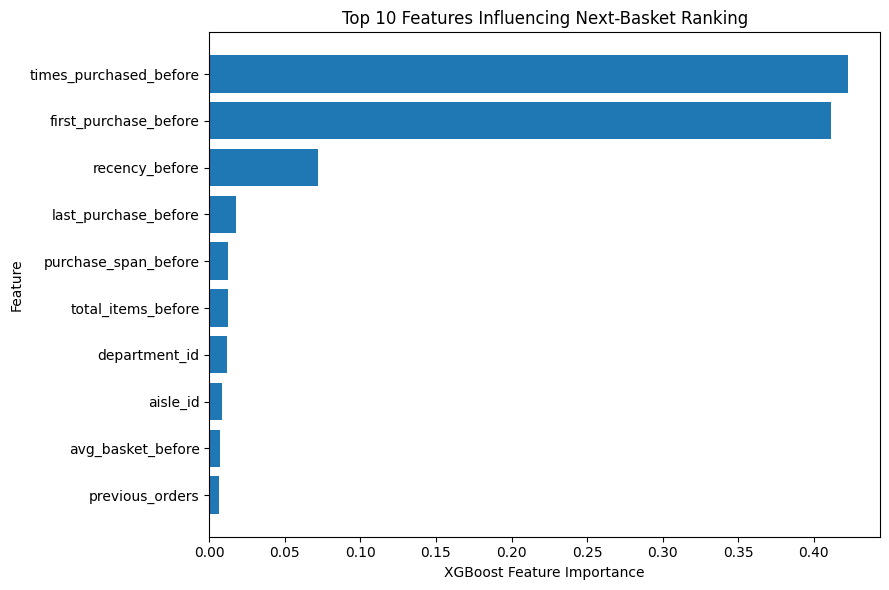

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Next-Basket Ranking")
plt.tight_layout()
plt.show()

In [ ]:
output_path = f"{base_path}/Model_Outputs"
os.makedirs(output_path, exist_ok=True)

model.save_model(f"{output_path}/xgboost_next_basket_ranker.json")

metrics_df.to_csv(
    f"{output_path}/xgboost_validation_metrics.csv",
    index=False
)

baseline_df.to_csv(
    f"{output_path}/baseline_validation_metrics.csv",
    index=False
)

comparison.to_csv(
    f"{output_path}/model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    f"{output_path}/feature_importance.csv",
    index=False
)

sample_recommendations.to_csv(
    f"{output_path}/sample_top10_recommendations.csv",
    index=False
)

print("Notebook 5 outputs saved successfully.")
print("Output folder:", output_path)

Notebook 5 outputs saved successfully.
Output folder: /content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Model_Outputs
